# 異常検知における前処理

取得したデータがそのままではモデルに入力できない形式の場合や、モデルの性能を十分に引き出せない特性を持つ場合は、モデル構築に先立って**前処理**（preprocessing）を行い、データの質を整える必要があります。
ここでは異常検知においてよく用いられる、以下の前処理をPythonで実装する方法を紹介します。

|書籍で解説している項|名称|必要になる場面|
|---|---|---|
|9.2.1|欠測値への対処|データに欠測値が含まれる場合|
|9.2.2|変数選択|変数の数が多すぎる、特定の変数の欠測値が極端に多い、多重共線性の悪影響が疑われるetc.|
|9.2.3|カテゴリ変数の数値化|カテゴリ変数をモデルに入力するための前処理|
|9.2.4|標準化と正規化||
|9.2.5|次元削減 ― 主成分分析|多重共線性や過学習の防止、モデルの軽量化、可視化や分析のしやすさの向上|
|9.2.6|外れ値検出|学習用の正常データから異常の恐れが高いデータを除外。モデリングに裾が長い分布を使用する必要性を判断|

## 9.2.1 欠測値への対処

実世界で得られる入力データの多くには欠測値（missing values）が含まれます。多くの異常検知アルゴリズムは欠測値を含んだままでは学習・推論できないため、欠測値を適切に補完または除外する必要があります。

このうち補完はサンプルサイズを減らさずに処理できるメリットがありますが、欠測値の発生メカニズムや補完法に関する深い知識が求められ、不用意に適用すると思わぬバイアスを生むリスクがあります。
ここでは正常データを大量に取得できることが多いという異常検知の特性を考慮して、もう片方の対処法である欠測値除外の実装法を解説します。

### リストワイズ削除

欠測値除外の中でも代表的かつ簡単に適用できる方法が、**リストワイズ削除**（listwise deletion）です。リストワイズ削除では、すべての変数の中に一つでも欠測がある場合、そのデータ（構造化データの行）を削除します。

Pythonでは、PandasのDataFrameの`dropna`メソッドを使うことで簡単にリストワイズ削除を実装できます。2章で作成したサンプルデータに適用する例を以下に示します。

In [21]:
# コード9.1 リストワイズ削除
import pandas as pd

# CSVからPandas DataFrameにデータ読み込み
df = pd.read_csv("https://raw.githubusercontent.com/ghmagazine/python_anomaly_detection_book/refs/heads/main/notebooks/datasets/ch2_dataset_train.csv")
# 正常データのみを抽出
df_normal = df[df["label"] == "normal"]
# リストワイズ削除でいずれかの変数に欠測値を含むデータを削除
df_dropna = df_normal.dropna()

print("元のデータ数:", len(df_normal))
print("リストワイズ削除後のデータ数:", len(df_dropna))

元のデータ数: 1000
リストワイズ削除後のデータ数: 854


### 変数名を指定した欠測値除外

リストワイズ削除をそのまま適用すると、モデルに入力しない変数に欠測値が含まれるデータまで削除されてしまうため、サンプルサイズが不必要に減ってしまう恐れがあります。`subset`引数に変数名をリスト指定すると、その変数に欠測があるデータのみを削除できます。実務では、後述の変数選択で選択した変数群をリスト指定するとよいでしょう。

In [22]:
# コード9.2 指定した変数群に欠測があるデータの削除
# "temp2","temp1"変数に欠測が含まれるデータを削除
df_dropna = df_normal.dropna(subset=['temp2', 'temp1'])

print("元のデータ数:", len(df_normal))
print("\"temp2\",\"temp1\"変数に欠測が含まれるデータ削除後のデータ数:", len(df_dropna))

元のデータ数: 1000
"temp2","temp1"変数に欠測が含まれるデータ削除後のデータ数: 912


## 9.2.2 変数選択

6章で述べたように、一般的に1変数のみを用いてモデリングするよりも、多変数を用いた方がデータ中の多くの情報を活用して高性能な異常検知を実現できます。一方で使える変数を全てモデルに入力することが常に最適とは限らず、変数の数が多すぎることは以下のような問題を起こす可能性があります。

- 相関の強い変数同士がモデルの学習を不安定にする（多重共線性）
- 変数が多いほど学習に必要なサンプルサイズが指数関数的に増える（次元の呪い）
- 欠測値が多い変数を含めることで、欠測値除外時にサンプルサイズが大幅に減る
- 説明可能性が低下する

このような問題を防ぐためには、モデルに入力する変数を減らす**変数選択**（feature selection）を適切に実施することが重要です。変数選択は根拠を持って選択する必要があります。

- 全変数をそのまま使用（強制投入法）
- 変数の全組み合わせで性能比較（総当たり法）
- 相関に基づく変数選択
- 有効サンプル数に基づく変数選択
- ドメイン知識に基づく変数選択
- ステップワイズ法

それぞれの方法の詳細については書籍で解説した通りのため、ここでは相関に基づく変数選択、およびステップワイズ法をPythonで実装する方法を紹介します

### 相関に基づく変数選択

変数選択において相関関係の強さを評価する指標として、**VIF**（variance inflation factor）と呼ばれる指標がよく用いられます。ある変数$x_k$に対するVIFは、この変数を目的変数として、残りの変数を説明変数とした線形回帰モデル

PythonでVIFを計算するには、Statsmodelsライブラリを利用すると便利です。2章で作成したサンプルデータの各変数（`temp1`〜`temp5`）に対してVIFを計算する例を以下に示します。

In [23]:
# VIFの計算
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# CSVからPandas DataFrameにデータ読み込み
df = pd.read_csv("https://raw.githubusercontent.com/ghmagazine/python_anomaly_detection_book/refs/heads/main/notebooks/datasets/ch2_dataset_train.csv")
# 正常データのみを抽出
df_normal = df[df["label"] == "normal"]
# リストワイズ削除でいずれかの変数に欠測値を含むデータを削除
df_dropna = df_normal.dropna()

# 説明変数に絞る
df_var = df_dropna.drop("label", axis=1)
df_var = sm.add_constant(df_var)  # 切片（定数項）を追加
# VIFを計算
vif = [variance_inflation_factor(df_var.to_numpy(), i)
       for i in range(df_var.shape[1])]
print(pd.Series(vif, index=df_var.columns))

const    11561.001580
temp1        1.548316
temp2        1.970598
temp3        1.735629
temp4        1.003088
temp5        1.004415
dtype: float64


VIFは1以上の値をとり、他変数との相関が強いほど数字が大きくなります。多重共線性があるかを判断するためのしきい値として、5や10よく用いられますが、ここでは以下のような判断基準を用いることとします。

- 1〜5 → 問題なし
- 5〜10 → 少し注意
- 10以上 → 多重共線性のリスクが高い

今回は全ての変数に関してVIFが2以下のため、多重共線性を懸念した変数選択は不要と判断できそうです（切片`const`に関するVIFは意味を持たないので、無視してください）。

### ステップワイズ法

**ステップワイズ法**（step wise）は、特定の性能評価指標に基づいて逐次的に変数を追加・削除することで、⾃動化された変数選択を実現できます。
ステップワイズ法は変数を選択する順序で、⼤きく以下の2種類の方法に分けられます。

- Forward法：変数を一切含まないモデルから始め、評価指標または有意性が高い変数を一つずつ加えていく
- Backward法：すべての変数を含むモデルから始め、評価指標または有意性が低い変数を一つずつ除外していく

両者のフローチャートは以下のようになります。

![fig9_1.png](https://raw.githubusercontent.com/ghmagazine/python_anomaly_detection_book/refs/heads/main/notebooks/images/fig9_1.png)

Forward法、Backward法を、それぞれPythonで実装してみます。
データセットには2章で作成したサンプルデータを、モデルには6章で解説した多変数のホテリング理論を用いることとします。
まずは以下のようにデータの読込と前処理を実施します。

In [24]:
import numpy as np
import pandas as pd

# CSVからPandas DataFrameにデータ読み込み
df = pd.read_csv("https://raw.githubusercontent.com/ghmagazine/python_anomaly_detection_book/refs/heads/main/notebooks/datasets/ch2_dataset_train.csv")
# リストワイズ削除でいずれかの変数に欠測値を含むデータを削除
df_dropna = df.dropna()

ここから変数選択を実施していきますが、評価指標として以下の2種類どちらを用いるかで注意点が変わるので、それぞれ解説します。

- 書籍9.3.1節で解説した「**ラベルの予測精度**」（例：精度、F値、AU-ROC。正常・異常データ両方を使用）
- 書籍9.3.2節で解説した「**統計モデル選択の妥当性**」（例：AIC、BIC、WAIC。正常データのみを使用）

#### 「ラベルの予測精度」を評価指標とする場合（正常・異常データ両方を使用）

評価指標に「ラベルの予測精度」を用いるケースを考えます。ここでは例としてF値を用いることとします。

まずは以下のようにデータを説明変数と目的変数に分けた上で、Numpyのndarrayに変換します。


In [25]:
# Numpyのndarrayに変換
X = df_dropna.drop("label", axis=1).to_numpy()  # 説明変数
y = df_dropna["label"].to_numpy()  # 目的変数
raw_features = df_dropna.columns.drop("label")  # 選択前の全ての説明変数名リスト

次にF値を計算する関数を実装します（F値の計算方法については[ch9_3_Classification_Metrics.ipynb](https://github.com/ghmagazine/python_anomaly_detection_book/blob/main/notebooks/ch9_3_Classification_Metrics.ipynb)も参照してください）。

In [26]:
# F値を交差検証で計算する関数
from scipy import stats
from sklearn.metrics import f1_score

def calculate_f1_normal(X, y, cv, target_fp_rate):
    """
    最尤推定した`n_features`次元正規分布のF値を交差検証で計算する関数

    Parameters
    ----------
    X : ndarray, shape (N, M) or shape (N,)
        入力データ（正常データ＋異常データ）
    y : ndarray, shape (N,)
        正常データ:0、異常データ:1のラベル
    cv : sklearn.model_selection._split.BaseCrossValidator
        交差検証の分割オブジェクト
    target_fp_rate : float
        ターゲットとする誤報率
    """
    n_features = X.shape[1] if X.ndim > 1 else 1 # 変数の数M
    n = X.shape[0] # データ数N
    # 交差検証の結果（F値）を格納するリスト
    f1s = []
    # 交差検証の実行
    for train_index, test_index in cv.split(X, y):
        # 学習データとテストデータに分割
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        # 正常のモデル（M次元正規分布）を学習
        if n_features > 1:  # 多次元の場合
            mu = np.mean(X_train, axis=0) # 標本平均ベクトルμ
            sigma = np.cov(X_train.T, ddof=0) # 標本分散共分散行列Σ
            # 異常度を算出（式6.45に従う）
            X_dev = (X_test-np.array(mu)).T # 推論データと平均ベクトルとの差（x-μ）
            Sigma_inv = np.linalg.inv(np.array(sigma)) # 標本分散共分散行列の逆行列
            Dev_Sigma = X_dev.T @ Sigma_inv # (x-μ)^T * Σ^-1
            anomaly_scores = np.sum(np.multiply(Dev_Sigma, X_dev.T), axis=1)
        else:  # 1次元の場合
            mu = np.mean(X_train) # 標本平均値μ
            sigma = np.var(X_train) # 標本分散σ^2
            # 異常度を算出（式4.21に従う）
            anomaly_scores = ((X_test - mu) ** 2) / sigma
        # ⾃由度（M）のカイ二乗分布の累積分布関数の逆関数からしきい値算出
        a_th = stats.chi2.ppf(1 - target_fp_rate, df=n_features)
        # しきい値により異常の有無を推論
        y_pred = np.where(anomaly_scores > a_th, 'anomaly', 'normal')
        # F値を計算してリストに追加
        f1 = f1_score(y_test, y_pred, pos_label='anomaly')
        f1s.append(f1)
    # F値の平均を計算して返す
    return float(np.mean(f1s))

F値の計算に使用する`f1_score`関数を他のsckikit-learnの関数（`accuracy_score`、`precision_score`、`recall_score`、`auc`など）に変えることで、他の評価指標にも対応可能です。

ここからForward法、Backword法に分けて実装法を解説します。

##### Forward法

Forward法では、説明変数を含まない空モデルからスタートし、まだモデルに含めていない変数を1つずつ加えて最も性能が上がる変数をモデルに追加する、という操作を繰り返します。

なお、先ほどのフローチャートでは選択する変数の数を予め決めていましたが、性能の上昇幅に下限を設け、下限を下回った時点で変数の追加を打ち切る方法もあります。ただしこの方法はF値のような「ラベルの予測精度」には適用できますが、後述する「統計モデル選択の妥当性」を評価指標として用いる場合は、変数の数が異なるモデルを直接比較できないため、適用できません。

今回は選択する変数の数を2個とし、以下のようなPythonコードでForward法を実装します。過学習状態での評価を防ぐために、交差検証を実施する必要があることにご注意ください（交差検証の詳細については[ch9_3_Cross_Varidation_And_Parameter_Tuning.ipynb](https://github.com/ghmagazine/python_anomaly_detection_book/blob/main/notebooks/ch9_3_Cross_Varidation_And_Parameter_Tuning.ipynb)も参照してください）

In [27]:
from sklearn.model_selection import StratifiedKFold

# Forward法による変数選択（評価指標にF値を使用）
TARGET_FP_RATE = 0.0027 # ターゲットとする誤報率（正規分布の3σ相当=0.0027）
N_SELECT = 2  # 選択する変数の数
selected_vars = []  # 選択された変数のリスト
remaining_vars = list(raw_features)  # 選択されていない変数のリスト
# 交差検証用（Stratified K-Fold）のインスタンスを作成
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

current_score = -np.inf  # F値の初期値（大きいほど良い前提）
best_new_score = -np.inf

# 変数選択ループ
for i in range(N_SELECT):
    scores_with_candidates = []
    for candidate in remaining_vars:
        # 選択済み変数に候補変数を追加してデータを抽出
        vars_to_use = selected_vars + [candidate]
        X_subset = X[:, [list(raw_features).index(var) for var in vars_to_use]]
        if X_subset.shape[1] == 1:
            X_subset = X_subset.flatten()  # 1説明変数の場合、1次元配列に変換
        # F値を計算
        f1 = calculate_f1_normal(X_subset, y, skf, target_fp_rate=TARGET_FP_RATE)
        scores_with_candidates.append((f1, candidate))
        print(f"候補変数: {candidate}, F値: {f1}")
    # 最もF値が大きい変数を選択
    scores_with_candidates.sort(reverse=True)
    best_new_score, best_candidate = scores_with_candidates[0]
    # 選択された変数をリストに追加し、選択されていない変数リストから削除
    remaining_vars.remove(best_candidate)
    selected_vars.append(best_candidate)
    current_score = best_new_score
    print(f"選択された変数: {selected_vars}, F値: {best_new_score}")

候補変数: temp1, F値: 0.21333333333333332
候補変数: temp2, F値: 0.6761904761904762
候補変数: temp3, F値: 0.37333333333333335
候補変数: temp4, F値: 0.0
候補変数: temp5, F値: 0.0
選択された変数: ['temp2'], F値: 0.6761904761904762
候補変数: temp1, F値: 0.5942857142857142
候補変数: temp3, F値: 0.5466666666666666
候補変数: temp4, F値: 0.5085714285714286
候補変数: temp5, F値: 0.5847619047619047
選択された変数: ['temp2', 'temp1'], F値: 0.5942857142857142


選択された変数は`['temp2', 'temp1']`となりましたが、これは2章のEDAにおける異常と正常の分離性が高い変数と一致しています。このようにF値のような「ラベルの予測精度」は、「異常と正常を効率よく見分ける」という異常検知の目的のダイレクトな評価に適した指標といえます。

##### Backward法

Backward法では、すべての変数を含むモデルからスタートし、変数を1つずつ減らして性能の低下量が最も小さい変数をモデルから除外する、という操作を繰り返します。

今回は選択する変数の数を2個（除外する変数の数を3個）とし、以下のようなPythonコードでBackward法を実装します。

In [28]:
# Backward法による変数選択（評価指標にF値を使用）
TARGET_FP_RATE = 0.0027 # ターゲットとする誤報率（正規分布の3σ相当=0.0027）
N_SELECT = 2  # 選択する変数の数
removed_vars = []  # 選択から除外された変数のリスト
remaining_vars = list(raw_features)  # 残っている変数のリスト

current_score = -np.inf  # F値の初期値（大きいほど良い前提）
best_new_score = -np.inf
n_features = len(remaining_vars)
# 交差検証用（Stratified K-Fold）のインスタンスを作成
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 変数除外前の性能を計算
f1 = calculate_f1_normal(X, y, skf, target_fp_rate=TARGET_FP_RATE)
print(f"全変数使用時のF値: {f1}")

# 変数除外ループ
for i in range(n_features - N_SELECT):
    scores_with_candidates = []
    for candidate in remaining_vars:
        # 元々の変数から候補変数を除外してデータを抽出
        vars_to_use = [var for var in remaining_vars if var != candidate]
        X_subset = X[:, [list(raw_features).index(var) for var in vars_to_use]]
        if X_subset.shape[1] == 1:
            X_subset = X_subset.flatten()  # 1説明変数の場合、1次元配列に変換
        # F値を計算
        f1 = calculate_f1_normal(X_subset, y, skf, target_fp_rate=TARGET_FP_RATE)
        scores_with_candidates.append((f1, candidate))
        print(f"候補変数: {candidate}, F値: {f1}")
    # 除外後のF値が最も大きい変数を選択
    scores_with_candidates.sort(reverse=True)
    best_new_score, best_candidate = scores_with_candidates[0]
    # 除外された変数をリストに追加し、残っている変数リストから削除
    remaining_vars.remove(best_candidate)
    removed_vars.append(best_candidate)
    current_score = best_new_score
    print(f"除外された変数: {removed_vars}, 残っている変数: {remaining_vars}, F値: {best_new_score}")

全変数使用時のF値: 0.4647619047619047
候補変数: temp1, F値: 0.48
候補変数: temp2, F値: 0.13333333333333333
候補変数: temp3, F値: 0.4647619047619047
候補変数: temp4, F値: 0.4133333333333333
候補変数: temp5, F値: 0.4514285714285714
除外された変数: ['temp1'], 残っている変数: ['temp2', 'temp3', 'temp4', 'temp5'], F値: 0.48
候補変数: temp2, F値: 0.22666666666666666
候補変数: temp3, F値: 0.4323809523809524
候補変数: temp4, F値: 0.49333333333333335
候補変数: temp5, F値: 0.4609523809523809
除外された変数: ['temp1', 'temp4'], 残っている変数: ['temp2', 'temp3', 'temp5'], F値: 0.49333333333333335
候補変数: temp2, F値: 0.37333333333333335
候補変数: temp3, F値: 0.5847619047619047
候補変数: temp5, F値: 0.5466666666666666
除外された変数: ['temp1', 'temp4', 'temp3'], 残っている変数: ['temp2', 'temp5'], F値: 0.5847619047619047


最初に除外された`temp1`は、2章のEDAにおいて`temp2`の次に異常と正常の分離性が高い変数であり、直感的には少し不思議な結果です。これは`temp2`単体でも十分高い性能が出せている（Forward法で`temp2`のみの方が`temp1`,`temp2`の2変数を用いた場合よりも性能が高いことからも分かる）ため、`temp1`を除外してもあまり性能が落ちない（今回はむしろ性能が上がっている）ことや、`temp1`と`temp3`の相関があることから片方を除外しても情報の損失が少ないことが原因として考えられます。

#### 「統計モデル選択の妥当性」を評価指標とする場合（正常データのみを使用）

評価指標に「統計モデル選択の妥当性」を用いるケースを考えます。ここでは例としてAICを用いることとします。
まずは以下のように、正常データのみを抽出してNumpyのndarrayに変換します。

In [29]:
# 正常データのみを抽出
df_normal = df[df["label"] == "normal"]
# Numpyのndarrayに変換
X_train = df_dropna.drop("label", axis=1).to_numpy()
raw_features = df_dropna.columns.drop("label")  # 選択前の全ての変数名リスト

次にAICを計算する関数を実装します（AICの計算方法については[ch9_3_Statistical_Model_Metrics.ipynb](https://github.com/ghmagazine/python_anomaly_detection_book/blob/main/notebooks/ch9_3_Statistical_Model_Metrics.ipynb)も参照してください）

In [30]:
# AICを計算する関数
def calculate_aic_normal(X):
    """
    最尤推定した`n_features`次元正規分布のAICを計算する関数

    Parameters
    ----------
    X : ndarray, shape (N, M) or shape (N,)
        入力データ（正常データのみ）
    """
    n_features = X.shape[1] if X.ndim > 1 else 1 # 変数の数M
    n = X.shape[0] # データ数N
    # 多次元の場合
    if n_features > 1:
        # 平均ベクトルと分散共分散行列を計算
        mu = np.mean(X, axis=0)
        sigma = np.cov(X.T, ddof=0)
        # 対数尤度の計算（書籍の式 (9.17)参照）
        X_dev = (X-np.array(mu)).T # 推論データと平均ベクトルとの差（x-μ）、統計形式に直すための転置に注意
        Sigma_inv = np.linalg.inv(np.array(sigma)) # 標本分散共分散行列の逆行列
        Dev_Sigma = X_dev.T @ Sigma_inv # (x-μ)^T * Σ^-1
        anomaly_scores = np.sum(np.multiply(Dev_Sigma, X_dev.T), axis=1)
        first_term = np.log(2*np.pi) * n_features/2 # M/2log(2π)
        second_term = 0.5 * np.log(np.linalg.det(sigma)) # 1/2 log|Σ|
        log_likelihood = -n*(first_term+second_term) - 0.5*np.sum(anomaly_scores)
    # 1次元の場合
    else:
        # 平均値と分散を計算
        mu = np.mean(X)
        sigma = np.var(X, ddof=0)
        # 対数尤度の計算（書籍の式 (4.22)参照）
        log_likelihood = -n * np.log(2 * np.pi) / 2 - n * np.log(sigma) / 2 - \
                         np.sum((X - mu) ** 2) / (2 * sigma)
    # モデルのパラメータ数
    p = n_features # 平均ベクトルμの要素数（変数の数）
    k = p + p * (p + 1) / 2 # 共分散行列Σのユニーク要素数を足す
    # AICの計算
    aic = 2*k - 2*log_likelihood
    return float(aic)

ここからForward法、Backword法に分けて実装法を解説します。

##### Forward法

「統計モデル選択の妥当性」では、基本的に変数の数が異なるモデルを直接比較できません。よって性能の上昇幅に下限を設けて変数の追加を打ち切る方法は適用できず、予め選択する変数の数を定める必要があります。
よって今回は選択する変数の数を予め3個とし、以下のようなPythonコードでForward法を実装します。

In [31]:
# Forward法による変数選択（評価指標にAICを使用）
N_SELECT = 3  # 選択する変数の数
selected_vars = []  # 選択された変数のリスト
remaining_vars = list(raw_features)  # 選択されていない変数のリスト

current_score = np.inf  # AICの初期値（小さいほど良い前提）
best_new_score = np.inf

# 変数選択ループ
for i in range(N_SELECT):
    scores_with_candidates = []
    for candidate in remaining_vars:
        # 選択済み変数に候補変数を追加してデータを抽出
        vars_to_use = selected_vars + [candidate]
        X_subset = X_train[:, [list(raw_features).index(var) for var in vars_to_use]]
        if X_subset.shape[1] == 1:
            X_subset = X_subset.flatten()  # 1変数の場合、1次元配列に変換
        # AICを計算
        aic = calculate_aic_normal(X_subset)
        scores_with_candidates.append((aic, candidate))
        print(f"候補変数: {candidate}, AIC: {aic}")
    # 最もAICが小さい変数を選択
    scores_with_candidates.sort()
    best_new_score, best_candidate = scores_with_candidates[0]
    # 選択された変数をリストに追加し、選択されていない変数リストから削除
    remaining_vars.remove(best_candidate)
    selected_vars.append(best_candidate)
    current_score = best_new_score
    print(f"選択された変数: {selected_vars}, AIC: {best_new_score}")

候補変数: temp1, AIC: 5389.711479417495
候補変数: temp2, AIC: 5614.841401948741
候補変数: temp3, AIC: 5069.256690752199
候補変数: temp4, AIC: 4329.779893402365
候補変数: temp5, AIC: 4419.069091478585
選択された変数: ['temp4'], AIC: 4329.779893402365
候補変数: temp1, AIC: 9720.465761484596
候補変数: temp2, AIC: 9946.102610741082
候補変数: temp3, AIC: 9400.283813842587
候補変数: temp5, AIC: 8750.806404716195
選択された変数: ['temp4', 'temp5'], AIC: 8750.806404716195
候補変数: temp1, AIC: 14142.232714363645
候補変数: temp2, AIC: 14368.821236206002
候補変数: temp3, AIC: 13823.015650998568
選択された変数: ['temp4', 'temp5', 'temp3'], AIC: 13823.015650998568


選択された変数は`['temp4', 'temp5', 'temp3']`となりましたが、これは2章のEDAにおける異常と正常の分離性が高い変数（`temp2`が最も高く、`temp1`と`temp3`がこれに続く）を選択できているとは言えません。AICやBICのような「統計モデル選択の妥当性」に基づく指標は、単純にモデルが正常データにフィットしているか（モデルが正常データを説明できるか）を評価しているため、異常と正常の判別能力とは関係性の低い指標となります（正常データによくフィッティングしたモデルは、異常の可能性が高い外れ値を効率よく検出できるため、完全に無関係ではありません）。AICやBICのような指標は、「異常と正常を効率よく見分ける」という異常検知の目的に対してダイレクトさに欠ける指標であることが、ここからも確認できます。

また、ほぼ変数の数に比例してAICの値が大きくなっています（詳細は割愛しますが、正規分布モデルでは各変数が独立であれば、AICは変数の数に比例します）。ここから先ほど述べた「AICのような指標では、変数の数が異なるモデルを直接比較できない」ことも確認できました。

余談ですが、[ch2_5_Create_Dataset.ipynb](https://github.com/ghmagazine/python_anomaly_detection_book/blob/main/notebooks/ch2_5_Create_Dataset.ipynb)でのサンプルデータ生成に用いた5次元正規分布では、`temp1`と`temp2`の相関が最も強く、`temp2`と`temp3`、`temp1`と`temp2`の相関がそれに続き、`temp4`と`temp5`は完全に独立となっていました。Forward法で選択された順番を見ると、独立に近い変数の方が早く選択され、AICの改善により寄与していることが分かります。この結果は、定性的には以下のような特性に由来します。

- 完全に独立な変数（`temp4`と`temp5`）は、追加すると尤度が大きく改善する
- 相関のある変数（`temp1`、`temp2`、`temp3`）は、すでに似た情報が入っているため、追加しても改善が小さい

##### Backward法

今回は選択する変数の数を2個（除外する変数の数を3個）とし、以下のようなPythonコードでBackward法を実装します。

In [32]:
# Backward法による変数選択（評価指標にAICを使用）
N_SELECT = 3  # 選択する変数の数
removed_vars = []  # 選択から除外された変数のリスト
remaining_vars = list(raw_features)  # 残っている変数のリスト
n_features = len(remaining_vars)

current_score = np.inf  # AICの初期値（小さいほど良い前提）
best_new_score = np.inf

# 変数除外前の性能を計算
aic = calculate_aic_normal(X_train)
print(f"全変数使用時のAIC: {aic}")

# 変数除外ループ
for i in range(n_features - N_SELECT):
    scores_with_candidates = []
    for candidate in remaining_vars:
        # 選択済み変数に候補変数を追加してデータを抽出
        vars_to_use = [var for var in remaining_vars if var != candidate]
        X_subset = X_train[:, [list(raw_features).index(var) for var in vars_to_use]]
        if X_subset.shape[1] == 1:
            X_subset = X_subset.flatten()  # 1変数の場合、1次元配列に変換
        # AICを計算
        aic = calculate_aic_normal(X_subset)
        scores_with_candidates.append((aic, candidate))
        print(f"候補変数: {candidate}, AIC: {aic}")
    # 最もAICが小さい変数を選択
    scores_with_candidates.sort()
    best_new_score, best_candidate = scores_with_candidates[0]
    # 選択された変数をリストに追加し、選択されていない変数リストから削除
    remaining_vars.remove(best_candidate)
    removed_vars.append(best_candidate)
    current_score = best_new_score
    print(f"除外された変数: {removed_vars}, 残っている変数: {remaining_vars}, AIC: {best_new_score}")

全変数使用時のAIC: 23786.04878522581
候補変数: temp1, AIC: 18859.69645495782
候補変数: temp2, AIC: 18909.801070626345
候補変数: temp3, AIC: 19325.522732803485
候補変数: temp4, AIC: 19449.48662978038
候補変数: temp5, AIC: 19362.610229724487
除外された変数: ['temp1'], 残っている変数: ['temp2', 'temp3', 'temp4', 'temp5'], AIC: 18859.69645495782
候補変数: temp2, AIC: 13823.015650998568
候補変数: temp3, AIC: 14368.821236206002
候補変数: temp4, AIC: 14524.741523652528
候補変数: temp5, AIC: 14436.661965952731
除外された変数: ['temp1', 'temp2'], 残っている変数: ['temp3', 'temp4', 'temp5'], AIC: 13823.015650998568


Forward法と同じ変数が選択されました。

## 9.2.3 カテゴリ変数の数値化

カテゴリ変数（質的変数）は多くの異常検知アルゴリズムにおいて、そのままでは入力として用いることができません。カテゴリ変数を用いるには、数値に変換する必要があります。この変換処理を**エンコーディング**（encoding）と呼びます。
代表的なエンコーディング手法には、以下が挙げられます。

- one-hot encoding
- ordinal encoding

### one-hot encoding

one-hot encodingはカテゴリ変数のユニーク値ごとにダミー変数を作成する方法です。変換後のダミー変数は、対応するユニーク値が変換前のカテゴリ変数と等しい場合に1を、そうでない場合は0をとります。

ユニーク値全てに対応するダミー変数を作成すると冗長になるため、下の図の「冗長な変数を除去する場合」のように、一つを除去することが一般的です。

![fig9_2.png](https://raw.githubusercontent.com/ghmagazine/python_anomaly_detection_book/refs/heads/main/notebooks/images/fig9_2.png)

Pythonでは、scikit-learnの[sklearn.preprocessing.OneHotEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html)クラスを用いると、one-hot encodingを簡単に実装できます。例えば7章の中古車データセットの"model_name"という列名で表されるカテゴリ変数にone-hot encodingを適用する場合、以下のように実装します。

In [33]:
# コード9.3 one-hot encoding
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# CSVからPandas DataFrameに学習データ読み込み
df_train = pd.read_csv('https://raw.githubusercontent.com/ghmagazine/python_anomaly_detection_book/refs/heads/main/notebooks/datasets/usedcar_dataset_train.csv')
df_train = df_train[df_train['label'] == 'normal']  # 正常データのみを抽出
# CSVからPandas DataFrameに推論データ読み込み
df_inference = pd.read_csv('https://raw.githubusercontent.com/ghmagazine/python_anomaly_detection_book/refs/heads/main/notebooks/datasets/usedcar_dataset_inference.csv')
df_inference = df_inference[df_inference['label'] == 'normal']  # 正常データのみを抽出

# one-hot encoding用インスタンス作成（`drop`引数で最初の冗長な変数を削除）
enc = OneHotEncoder(drop='first')
# 学習データからカテゴリを学習（カテゴリ変数'model_name'の数値化）
enc.fit(df_train[['model_name']].to_numpy())

# 推論データに対してone-hot encodingを適用（numpy.ndarray形式の2次元配列で出力される）
encoded_species = enc.transform(df_inference[['model_name']].to_numpy()).toarray()
# one-hot encoding後のダミー変数をPandas DataFrameに変換
encoded_species = pd.DataFrame(encoded_species,
                               columns=enc.get_feature_names_out(['model_name']))
encoded_species

,model_name_sedan,model_name_suv
0,0.0,1.0
1,0.0,1.0
2,1.0,0.0
3,1.0,0.0
4,1.0,0.0
...,...,...
495,0.0,0.0
496,0.0,0.0
497,1.0,0.0
498,0.0,1.0


one-hot encoding後のダミー変数の名前は`get_feature_names_out`メソッドで取得できるので、これをPandasのDataFrameの列名に指定すると扱いやすくなります。

### ordinal encoding

ordinal encodingは以下の図に示すように、カテゴリ変数のユニーク値に連番で数値を割り当てる方法です。

![fig9_3.png](https://raw.githubusercontent.com/ghmagazine/python_anomaly_detection_book/refs/heads/main/notebooks/images/fig9_3.png)

割り振られた数値の差分は意味を持たないため、厳密には変換後も質的変数のままと言えます。そのため利用できるアルゴリズムは限定的で、ランダムフォレストやXGBoostのような決定木系アルゴリズム（）の説明変数や、[ch8_8_GLMM_Group_Random_Effect](https://github.com/ghmagazine/python_anomaly_detection_book/blob/main/notebooks/appendix/ch8_8_GLMM_Group_Random_Effect.ipynb)で紹介するグループ差によるランダム効果を含むGLMMにおけるグループのインデックスに利用できます。

Pythonでは、scikit-learnの[sklearn.preprocessing.OrdinalEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html)クラスを用いると、ordinal encodingを簡単に実装できます。例えば7章の中古車データセットの"model_name"という列名で表されるカテゴリ変数にordinal encodingを適用する場合、以下のように実装します。

In [34]:
# コード9.4 ordinal encoding
from sklearn.preprocessing import OrdinalEncoder

# ordinal encoding用インスタンス作成
enc = OrdinalEncoder(dtype=int)
# 学習データからカテゴリを学習（カテゴリ変数'model_name'の数値化）
enc.fit(df_train[['model_name']].to_numpy())

# 推論データに対してordinal encodingを適用（numpy.ndarray形式のベクトルで出力される）
encoded_species = enc.transform(df_inference[['model_name']].to_numpy())[:,0]
encoded_species

array([2, 2, 1, 1, 1, 0, 2, 0, 2, 1, 0, 2, 0, 2, 1, 2, 2, 0, 1, 1, 2, 2,
       2, 2, 2, 1, 2, 2, 2, 2, 2, 0, 2, 2, 1, 1, 1, 1, 2, 1, 2, 1, 2, 0,
       2, 1, 1, 1, 0, 0, 0, 0, 2, 2, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1,
       1, 2, 2, 1, 1, 0, 0, 1, 0, 2, 0, 0, 1, 0, 2, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 2, 1, 1, 2, 2, 1, 1, 1, 2, 1, 0, 0, 2, 2, 1, 1, 1, 2, 1, 0,
       1, 2, 0, 1, 1, 1, 0, 1, 1, 2, 0, 2, 2, 1, 1, 2, 2, 0, 2, 1, 2, 1,
       2, 2, 0, 1, 1, 1, 0, 1, 2, 1, 2, 1, 0, 2, 0, 2, 1, 0, 2, 2, 0, 2,
       0, 2, 2, 1, 1, 1, 1, 1, 2, 2, 1, 1, 2, 2, 0, 1, 1, 2, 0, 0, 1, 1,
       2, 0, 1, 2, 1, 0, 1, 1, 2, 0, 0, 1, 2, 2, 0, 0, 2, 2, 0, 1, 0, 1,
       0, 1, 0, 0, 1, 1, 2, 0, 1, 0, 1, 0, 1, 2, 0, 2, 1, 1, 2, 1, 2, 1,
       2, 0, 0, 0, 1, 1, 1, 1, 2, 2, 2, 1, 0, 2, 2, 2, 2, 2, 2, 2, 0, 2,
       0, 1, 0, 0, 2, 2, 2, 0, 2, 1, 2, 0, 2, 0, 1, 0, 0, 2, 2, 1, 0, 0,
       2, 2, 0, 1, 2, 0, 1, 1, 1, 2, 0, 2, 2, 2, 1, 2, 2, 2, 2, 0, 1, 0,
       1, 2, 1, 2, 0, 2, 1, 2, 0, 0, 0, 2, 2, 0, 1,

## 9.2.4 標準化と正規化

標準化と正規化は、各変数のスケールを揃えるための前処理です。両者のメカニズムと使い分け方法の概要は以下のようになります。

||算出式|用いられるパラメータ|スケール変換後の最大最小値|典型的な活用場面|
|---|---|---|---|---|
|標準化|$x'_j=\frac{x_j-\mu_j}{\sigma_j}$|平均0、標準偏差1にスケール|不定（平均0、標準偏差1）|SVMやk-NNのような特徴空間上距離に基づくアルゴリズムの前処理|
|正規化|$x''_j=\frac{x_j-min(x_j)}{max(x_j)-min(x_j)}$|値域（range）を[0,1]に揃える|最小値0、最大値1|外れ値も含めたデータの可視化、深層学習の中間層処理（batch normalization）|

### 標準化

**標準化**（standardization）は、学習データの標本平均$\mu_j$と標本標準偏差$\sigma_j$を用いて各変数のスケールを揃える処理です。$j$番目の変数を$x_j$としたとき、標準化後の変数$x'_j$は以下の式で表されます。

$x'_j=\frac{x_j-\mu_j}{\sigma_j}$

Pythonでは、scikit-learnの[sklearn.preprocessing.StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)クラスを用いると、標準化を簡単に実装できます。2章で作成したサンプルデータに適用する例を以下に示します。

In [35]:
# コード9.5 標準化
from sklearn.preprocessing import StandardScaler

# CSVから学習データ読み込み
df_train = pd.read_csv("https://raw.githubusercontent.com/ghmagazine/python_anomaly_detection_book/refs/heads/main/notebooks/datasets/ch2_dataset_train.csv")
df_train = df_train[df_train["label"] == "normal"].copy()  # 正常データのみを抽出
df_train = df_train.dropna()  # リストワイズ削除で欠測値削除
X_train = df_train.drop("label", axis=1).to_numpy()  # Numpyのndarrayに変換
# CSVから推論データ読み込み
df_inference = pd.read_csv("https://raw.githubusercontent.com/ghmagazine/python_anomaly_detection_book/refs/heads/main/notebooks/datasets/ch2_dataset_inference.csv")
df_inference = df_inference[df_inference["label"] == "normal"].copy()  # 正常データのみを抽出
df_inference = df_inference.dropna()  # リストワイズ削除で欠測値削除
X_inference = df_inference.drop("label", axis=1).to_numpy()  # Numpyのndarrayに変換

# 標準化用インスタンス作成
scaler = StandardScaler()
# 学習データから各列の標準偏差と平均を計算
scaler.fit(X_train)
# 推論データに対して標準化を適用（numpy.ndarray形式の2次元配列で出力される）
X_inference_std = scaler.transform(X_inference)
X_inference_std

array([[ 0.03290092,  0.18048451,  0.41738906, -0.72834834,  0.46539232],
       [ 0.49294772,  1.70937105,  1.91116287,  0.43588834, -0.76496959],
       [-1.35277929, -0.4726171 ,  0.03212413, -1.47057031,  1.69791013],
       ...,
       [-0.10552439, -0.4295268 , -0.50442326,  0.99412595, -0.16646293],
       [ 0.95552658,  1.51406426,  0.47941098, -1.31487195, -1.78642235],
       [-1.55105027, -0.69682368, -2.00567768,  0.22324721, -0.46643262]],
      shape=(432, 5))

実用上は実装をシンプルにするため、scikit-learnのパイプライン機能を用いて機械学習モデル（SVMやk-NNなど）とひとまとまりの処理にして用いることが多いでしょう。
以下に、3章で解説したSVMと標準化をパイプライン化した実装例を示します。

In [36]:
# SVMと標準化をパイプライン化
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# CSVから学習データ読み込み
df_train = pd.read_csv("https://raw.githubusercontent.com/ghmagazine/python_anomaly_detection_book/refs/heads/main/notebooks/datasets/ch2_dataset_train.csv")
df_train = df_train.dropna()  # リストワイズ削除で欠測値削除
X_train = df_train.drop("label", axis=1).to_numpy()  # Numpyのndarrayに変換
# 学習データの目的変数をnumpy.ndarray形式に変換
y_train = df_train["label"].to_numpy()
# CSVから推論データ読み込み
df_inference = pd.read_csv("https://raw.githubusercontent.com/ghmagazine/python_anomaly_detection_book/refs/heads/main/notebooks/datasets/ch2_dataset_inference.csv")
df_inference = df_inference.dropna()  # リストワイズ削除で欠測値削除
X_inference = df_inference.drop("label", axis=1).to_numpy()  # Numpyのndarrayに変換

# SVMモデル
svm = SVC(C=10, gamma=0.1)
# 標準化とSVMを合わせてパイプライン化する
clf = Pipeline([("scaler", StandardScaler()), ("svm", svm)])
clf.fit(X_train, y_train)  # 学習
# 推論データに対して標準化とSVMを適用
y_pred = clf.predict(X_inference)  # 推論

scikit-learnのパイプライン機能では、機械学習モデルの推論メソッドが`predict`という名称であれば（SVMはこの名称に該当）、パイプラインの`predict`メソッドを実行するだけで標準化と推論を連続実行できますが、`predict`以外の名称の推論メソッドを持つ場合、少し特殊な実装が必要となります。例としてk-NNでの実装例[ch6_6_kNN_Anomaly_Detection.ipynb](https://github.com/ghmagazine/python_anomaly_detection_book/blob/main/notebooks/ch6_6_kNN_Anomaly_Detection.ipynb)を参考にしてください。

### 正規化

**正規化**（normalization）は、学習データでの最⼤値$\max(x_j)$と最⼩$\min(x_j)$を用いて、各変数の値が$[0,1]$の範囲に収まるようにスケールを揃える方法です。$j$番目の変数を$x_j$としたとき、正規化後の変数$x''_j$は以下の式で表されます。

$x''_j=\frac{x_j-min(x_j)}{max(x_j)-min(x_j)}$

なお、広義には最小値と最大値を$[0,1]$以外の範囲（例$[-1,1]$）に収める方法も正規化と呼びますが、明示的に範囲を指定しない場合は$[0,1]$とすることが一般的です。

正規化はscikit-learnの[sklearn.preprocessing.MinMaxScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html)クラスで実装できます。標準化と同様のサンプルデータに適用する例を以下に示します。

In [37]:
# 正規化の適用
from sklearn.preprocessing import MinMaxScaler

# 正規化用インスタンス作成
scaler = MinMaxScaler()
# 学習データから各列の標準偏差と平均を計算
scaler.fit(X_train)
# 推論データに対して標準化を適用（numpy.ndarray形式の2次元配列で出力される）
X_inference_std = scaler.transform(X_inference)
X_inference_std

array([[0.40497969, 0.31242963, 0.47945379, 0.3627891 , 0.55978178],
       [0.4659504 , 0.4877661 , 0.68637965, 0.54287715, 0.35167845],
       [0.22133337, 0.23753033, 0.42608474, 0.2479797 , 0.76824977],
       ...,
       [0.78774042, 0.66590301, 0.6993699 , 0.58102433, 0.41945231],
       [0.76092216, 0.72016486, 0.79177088, 0.26072164, 0.35027139],
       [0.36172025, 0.75383016, 0.59746887, 0.69541303, 0.46464251]],
      shape=(442, 5))

### 9.2.5 次元削減―主成分分析

**次元削減**（dimension reduction）とは、高次元データの特徴をなるべく保持しながら、低次元データに変換する手法の総称です。次元削減を行うことで、変数選択と類似したメリットを享受することができます。例として多重共線性や過学習の防止、モデルの軽量化、可視化や分析のしやすさの向上が挙げられます。

次元削減の中でも最もよく使われる手法が、**主成分分析**（principal component analysis：PCA）です。主成分分析では、データの分散が最⼤となる方向に新たな軸を引き、この軸方向にデータを射影した値を新たな変数として採用します。分散が最⼤となる方向に軸をとることで、軸に沿った各データ間の距離が⼤きくなり、少ない軸でも効率よくデータを見分けるための情報を残せます。

注意点として、主成分分析は単純にデータの分布が広い=情報が多い方向に新たな軸を取るだけで、データが異常・正常どちらに属するかの情報は用いません。よって異常データと正常データの位置関係によっては、両者を見分けるための情報が次元削減によって失われてしまうこともあります。2次元での例として、以下の図のパターン1では次元削減後も正常・異常を見分けるための情報が残りますが、パターン2では両者を見分けることが困難となります。

![fig9_5.png](https://raw.githubusercontent.com/ghmagazine/python_anomaly_detection_book/refs/heads/main/notebooks/images/fig9_5.png)

それぞれのパターンを見分ける方法や対処法については、書籍を参照ください。またパターン2のPythonでの実装例は、[こちらの方のnotebook](https://github.com/mimikousi/anomaly-detection_R/blob/main/R_text_chapter5.ipynb)も参考になります。

ここでは主成分分析による次元削減（パターン1）を、2章で作成したサンプルデータに適用する例を示します。

正規化はscikit-learnの[sklearn.preprocessing.MinMaxScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html)クラスで実装できます。今回は元々5次元だったデータを、2次元に削減する例を示します。

Text(0, 0.5, 'PC2')

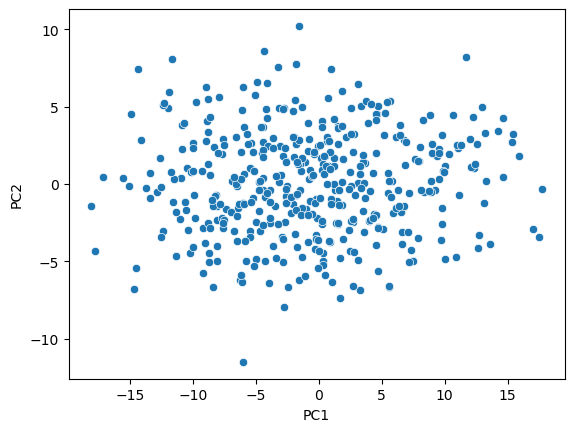

In [38]:
# 主成分分析による次元削減
from sklearn.decomposition import PCA

# CSVから学習データ読み込み
df_train = pd.read_csv("https://raw.githubusercontent.com/ghmagazine/python_anomaly_detection_book/refs/heads/main/notebooks/datasets/ch2_dataset_train.csv")
df_train = df_train[df_train["label"] == "normal"].copy()  # 正常データのみを抽出
df_train = df_train.dropna()  # リストワイズ削除で欠測値削除
X_train = df_train.drop("label", axis=1).to_numpy()  # Numpyのndarrayに変換
# CSVから推論データ読み込み
df_inference = pd.read_csv("https://raw.githubusercontent.com/ghmagazine/python_anomaly_detection_book/refs/heads/main/notebooks/datasets/ch2_dataset_inference.csv")
df_inference = df_inference[df_inference["label"] == "normal"].copy()  # 正常データのみを抽出
df_inference = df_inference.dropna()  # リストワイズ削除で欠測値削除
X_inference = df_inference.drop("label", axis=1).to_numpy()  # Numpyのndarrayに変換

# 学習データから第2主成分までを学習
pca = PCA(n_components=2)
pca.fit(X_train)
# 推論データに対して主成分分析を適用（numpy.ndarray形式の2次元配列で出力される）
X_inference_pca = pca.transform(X_inference)
X_inference_pca

# 主成分分析後のデータを散布図で可視化
import seaborn as sns
import matplotlib.pyplot as plt
sns.scatterplot(x=X_inference_pca[:,0], y=X_inference_pca[:,1])
plt.xlabel("PC1") # 横軸が第一主成分
plt.ylabel("PC2") # 縦軸が第二主成分

実用上は実装をシンプルにするため、scikit-learnのパイプライン機能を用いて機械学習モデル（SVMやk-NNなど）とひとまとまりの処理にすることも多いです。
以下に、3章で解説したSVMと主成分分析をパイプライン化した実装例を示します。

Text(0, 0.5, 'PC2')

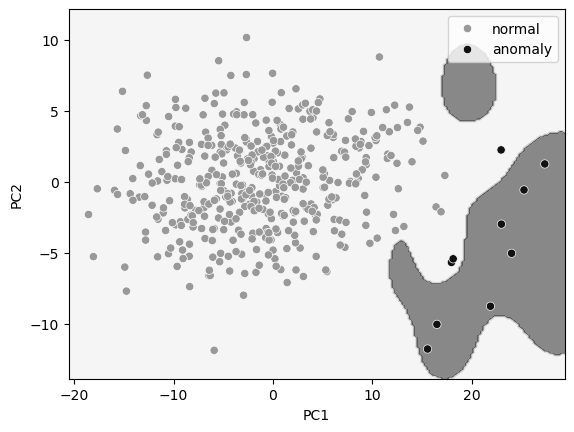

In [39]:
# SVMと主成分分析をパイプライン化
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

# CSVから学習データ読み込み
df_train = pd.read_csv("https://raw.githubusercontent.com/ghmagazine/python_anomaly_detection_book/refs/heads/main/notebooks/datasets/ch2_dataset_train.csv")
df_train = df_train.dropna()  # リストワイズ削除で欠測値削除
X_train = df_train.drop("label", axis=1).to_numpy()  # Numpyのndarrayに変換
# 学習データの目的変数をnumpy.ndarray形式に変換
y_train = df_train["label"].to_numpy()
# CSVから推論データ読み込み
df_inference = pd.read_csv("https://raw.githubusercontent.com/ghmagazine/python_anomaly_detection_book/refs/heads/main/notebooks/datasets/ch2_dataset_inference.csv")
df_inference = df_inference.dropna()  # リストワイズ削除で欠測値削除
X_inference = df_inference.drop("label", axis=1).to_numpy()  # Numpyのndarrayに変換

# SVMモデル
svm = SVC(C=10, gamma=0.1)
# 主成分分析とSVMを合わせてパイプライン化する
clf = Pipeline([("pca", PCA(n_components=2)), ("svm", svm)])
clf.fit(X_train, y_train)  # 学習
# 推論データに対して主成分分析とSVMを適用
y_pred = clf.predict(X_inference)  # 推論結果

# 主成分分析後の特徴空間で推論結果（決定境界）と正解ラベルを可視化
import numpy as np
from matplotlib import cm
X_inference_pca = clf.named_steps['pca'].transform(X_inference) # 主成分分析後の推論データ
x1_grid = np.linspace(X_inference_pca[:,0].min()-2,
                      X_inference_pca[:,0].max()+2, 200)
x2_grid = np.linspace(X_inference_pca[:,1].min()-2,
                      X_inference_pca[:,1].max()+2, 200)
X1, X2 = np.meshgrid(x1_grid, x2_grid)  # グリッドデータ作成
X_grid = np.c_[X1.ravel(), X2.ravel()]
pred_grid = clf.named_steps['svm'].predict(X_grid)  # グリッドデータに対する推論
pred_grid = np.where(pred_grid == 'normal', 1, 0)
# 決定境界の等高線をプロット
plt.contourf(X1, X2, pred_grid.reshape(X1.shape), cmap=cm.gray, alpha=0.5)
# 推論データの散布図をプロット（色は正解ラベル）
y_inference = df_inference["label"].to_numpy()  # 正解データ
sns.scatterplot(x=X_inference_pca[:,0], y=X_inference_pca[:,1], hue=y_inference,
                palette=['#999999', '#111111'])
plt.xlabel("PC1") # 横軸が第一主成分
plt.ylabel("PC2") # 縦軸が第二主成分

パイプラインは元の特徴空間に対する結果の確認や可視化を簡単に行うことができますが、今回のように主成分分析後の特徴空間に対する可視化を行うには一手間かける必要があります。パイプラインを使用すべきかどうかは、このような可視化や分析のニーズに合わせて判断すると良いでしょう。

## 9.2.6 外れ値検出

**外れ値**（outlier）とは、特徴空間上での位置が、他の⼤多数のデータと⼤きく異なるデータを指します。
異常検知においては外れ値に含まれるデータの性質（正常と異常どちらが多いか）に応じて、以下のように対処を変える必要があります。

- 外れ値に異常データが多い場合：モデルが過剰にばらつきを学習することを防ぐため、外れ値を学習データから除外する
- 外れ値に正常データが多い場合：外れ値の発生率が高い状態をモデリング可能な、裾の重い分布を正常のモデルとして選択する

これらの対処をとるためには、まず外れ値を検出する必要があります。構造化データにおける外れ値検出方法の代表例として、ここでは以下の手法のPythonでの実装法を解説します。

|No.|名称|使用できる場面|概要|標準化が必要か|
|---|---|---|---|---|
|1|IQRによる外れ値検出|1変数のみ|箱ひげ図で独立した点で表される範囲を外れ値とする|不要|
|2|マハラノビス距離によるしきい値判定|1変数、多変数|マハラノビス距離がしきい値以上のデータを外れ値とする（重心からの統計的距離が大きいほど外れ値判定されやすくなる）|不要|
|3|k-NN|1変数、多変数|k近傍距離がしきい値以上のデータを外れ値とする（周囲の点からの距離が遠いほど外れ値判定されやすくなる）|必要|
|4|LOF|1変数、多変数|周囲と比べたデータの存在密度の低さを表すLOFがしきい値以上のデータを外れ値とする（周囲の点と比べてデータ密度が低いほど外れ値判定されやすくなる）|必要|
|5|OC-SVM|1変数、多変数|データが分布する領域の境界を学習し、境界の外側にあるデータを外れ値とする|必要|

2章で作成したサンプルデータに対してこれらの手法による外れ値検出を適用します。まずは以下のようにデータを読み込みます。ここでは結果を可視化しやすいよう、変数を`temp2`、`temp1`の2個に絞ります（IQRではさらに`temp2`のみに絞ります）。

In [40]:
# CSVから学習データ読み込み
import pandas as pd

df_train = pd.read_csv("https://raw.githubusercontent.com/ghmagazine/python_anomaly_detection_book/refs/heads/main/notebooks/datasets/ch2_dataset_train.csv")
# "temp2","temp1"変数に絞ってNumpyのndarrayに変換
df_train = df_train.dropna(subset=['temp2', 'temp1'])  # 欠測値削除
X_train = df_train[['temp2', 'temp1']].to_numpy()

ここでは学習データに異常データが混入したケースを想定して、正常と異常両方を含んだデータを入力として用います。前述のように事前分析を目的としているので、学習データから求めた統計量や機械学習モデルに基づいて学習データに対して外れ値を検出します（学習データと検出用データを分けて検出してもOKです）。

### 1. IQRによる外れ値検出

1変数のみに適用できる簡易的な外れ値検出手法として、IQRによる外れ値検出が挙げられます。この方法では、箱ひげ図で独立した点で表される範囲、すなわち$第一四分位点-1.5\rm{IQR}$（$\rm{IQR}=第三四分位点-第一四分位点$）よりも下側、または$第三四分位点+1.5\rm{IQR}$よりも上側のデータを外れ値とみなします。

/var/folders/9f/r2qdz_xx5cb0t0vdjxq090kh0000gn/T/ipykernel_29549/3510448265.py:19: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.scatterplot(x=np.arange(len(x_train)), y=x_train,  # 散布図


Text(0, 0.5, 'temp2')

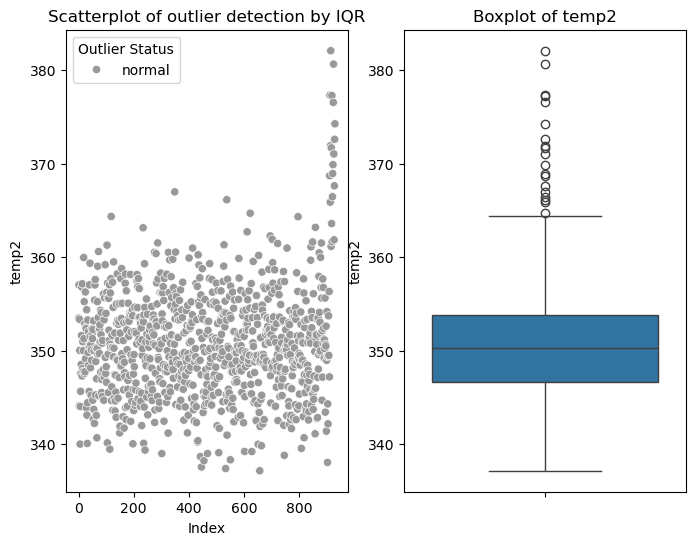

In [41]:
# IQRによる外れ値検出
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# "temp2"変数に絞ってNumpyのndarrayに変換
x_train = X_train[:, 0]

# IQRによる外れ値検出
q1 = np.quantile(X_train, 0.25)  # 第1四分位数
q3 = np.quantile(X_train, 0.75)  # 第3四分位数
iqr = q3 - q1  # 四分位範囲IQR
lower_bound = q1 - 1.5 * iqr  # 下限値
upper_bound = q3 + 1.5 * iqr  # 上限値
# 外れ値判定
outlier_prediction = np.where((x_train < lower_bound) | (x_train > upper_bound), 'outlier', 'normal')
# 散布図（左側の図）と箱ひげ図（右側の図）で可視化
fig, axes = plt.subplots(1, 2, figsize=(8, 6))
sns.scatterplot(x=np.arange(len(x_train)), y=x_train,  # 散布図
                hue=outlier_prediction,
                palette=['#999999', '#111111'], ax=axes[0])
sns.boxplot(y=x_train, ax=axes[1])  # 箱ひげ図
axes[0].set_title("Scatterplot of outlier detection by IQR")
axes[0].set_xlabel("Index")
axes[0].set_ylabel("temp2")
axes[0].legend(title="Outlier Status")
axes[1].set_title("Boxplot of temp2")
axes[1].set_ylabel("temp2")

左側の散布図がIQRによる外れ値判定（黒点が外れ値を表す）を表しています。右の箱ひげ図において独立した点で表されているデータが、外れ値として検出されていることがわかります。

### 2. マハラノビス距離によるしきい値判定

外れ値は⼤多数のデータから特徴空間上で外れたデータを指しますが、その検出には「正常データから統計的に外れたデータを検出する」という異常検知の考え方がマッチしていそうに見えます。実際、外れ値検出には異常検知と同様の手法が使われることが多いです。**多変数**における代表的な異常検知手法であるホテリング理論と同様の方法でも、外れ値を検出することができます。

この方法では、ホテリング理論の異常度の対数をとったマハラノビス距離

$\sqrt{a(x)} = \sqrt{(\boldsymbol{x}-\hat{\boldsymbol{\mu}})^\top \hat{\boldsymbol{\Sigma}}^{-1} (\boldsymbol{x}-\hat{\boldsymbol{\mu}})}$

にしきい値を設けて、マハラノビス距離がしきい値以上のデータを外れ値と判定します。

Text(0, 0.5, 'temp2')

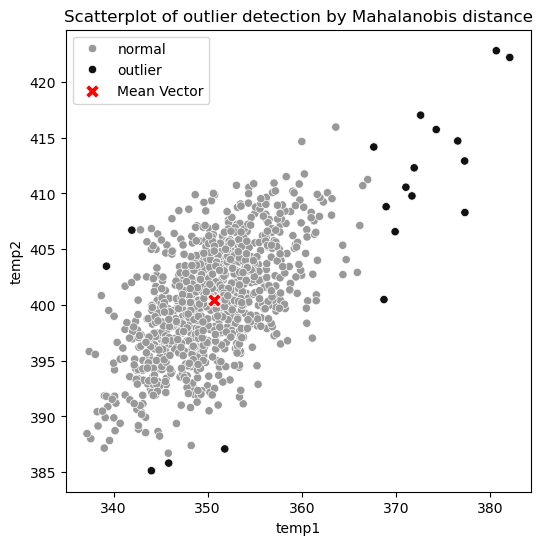

In [42]:
# マハラノビス距離による外れ値検出
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

THRESHOLD = 3

# 標本平均ベクトルと標本分散共分散行列を算出
mu = np.mean(X_train, axis=0)  # 標本平均ベクトルμ
Sigma = np.cov(X_train.T, ddof=0)  # 標本分散共分散行列Σ
# マハラノビス距離を算出
X_dev = (X_train - np.array(mu)).T  # 学習データと平均ベクトルとの差（x-μ）
Sigma_inv = np.linalg.inv(np.array(Sigma))  # 標本分散共分散行列の逆行列
Dev_Sigma = X_dev.T @ Sigma_inv  # (x-μ)^T * Σ^-1
mahalanobis_distances = np.sqrt(np.sum(np.multiply(Dev_Sigma, X_dev.T), axis=1))
# しきい値と比較して外れ値判定
outlier_prediction = np.where(mahalanobis_distances > THRESHOLD,
                              'outlier', 'normal')
# 散布図で可視化
plt.figure(figsize=(6, 6))
sns.scatterplot(x=X_train[:, 0], y=X_train[:, 1],  #散布図
                hue=outlier_prediction,
                palette=['#999999', '#111111'])
sns.scatterplot(x=[mu[0]], y=[mu[1]],  # 平均ベクトルを赤い点で表示
                color='red', s=100, label='Mean Vector', marker='X')
plt.title("Scatterplot of outlier detection by Mahalanobis distance")
plt.xlabel("temp1")
plt.ylabel("temp2")

マハラノビス距離の等高線は、平均ベクトル（重心）を中心に楕円形状となるため、重心からの（統計的）距離が遠いほど外れ値と判定されやすくなります。

この例ではマハラノビス距離のしきい値を予め与えていますが、ホテリング理論と同様にカイ二乗分布の累積分布関数の逆関数から求めることもできます。

### 3. k-NN

k-NNは、あるデータから特徴空間上でk番目に近い点をk近傍点、k近傍点までの距離をk近傍距離として求め、様々な処理を行う方法全般を指します。
6章では、k近傍距離を異常度として用いてしきい値を設ける異常検知方法を解説しましたが、同様のしきい値判定により外れ値検出にも用いることができます。

k-NNは特徴空間上での距離に基づく方法のため、一般的に前処理として標準化を実施する必要があります。以下に標準化とk-NNをパイプラインし、外れ値検出に用いる実装例を示します。

Text(0, 0.5, 'temp2')

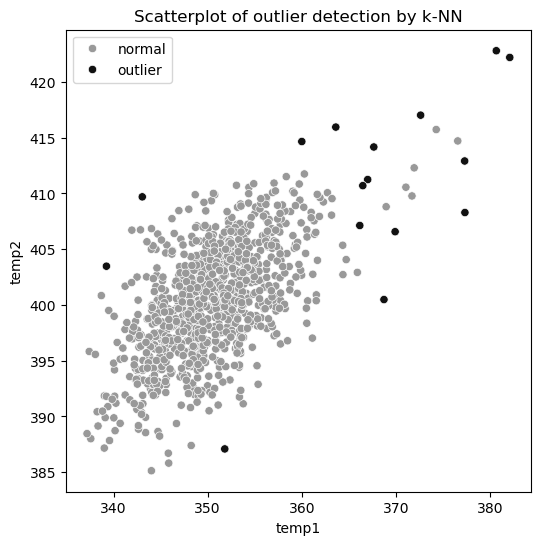

In [43]:
# k-NNによる外れ値の検出
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

N_NEIGHBORS = 3  # kの値
THRESHOLD = 0.5  # 第k近傍距離のしきい値

# k-NNモデルを作成
knn = NearestNeighbors(n_neighbors=N_NEIGHBORS, algorithm='auto', metric='minkowski')
# 標準化とパイプライン化する
pipe = Pipeline([("scaler", StandardScaler()), ("knn", knn)])
pipe.fit(X_train) # モデルを学習
# 学習データに対して標準化とk-NNを適用
X_train_std = pipe.named_steps[ # 標準化
    'scaler'].transform(X_train)
distances, indices = pipe.named_steps[ # k-NN適用
    'knn'].kneighbors(X_train_std)
distances = distances[:, -1]  # 第k近傍までの距離を取得
# しきい値と比較して外れ値判定
outlier_prediction = np.where(distances > THRESHOLD,
                              'outlier', 'normal')
# 散布図で可視化
plt.figure(figsize=(6, 6))
sns.scatterplot(x=X_train[:, 0], y=X_train[:, 1],  #散布図
                hue=outlier_prediction,
                palette=['#999999', '#111111'])
plt.title("Scatterplot of outlier detection by k-NN")
plt.xlabel("temp1")
plt.ylabel("temp2")

マハラノビス距離は重心からの（統計的）距離をもとに定義されていましたが、k-NNでは重心のようなデータ全体の傾向は見ておらず、周囲k点までの距離のみを見ています。よってこの方法は、周囲の点からの距離が遠いほど外れ値判定されやすくなる方法といえます。散布図の右上を見るとわかるように、重心から離れていても周囲k点までの距離が小さければ外れ値と判定されないので、マハラノビス距離による方法よりもややいびつな決定境界で検出されることとなります。

また、マハラノビス距離ではデータの斜め方向の偏在も考慮して距離のスケーリングが行われていましたが、k-NNでは前処理で各変数軸方向のスケーリングのみが調整されるため、斜め方向の偏在は考慮されません。

この例ではマハラノビス距離のしきい値を予め与えていますが、6章の異常検知におけるしきい値決定法と同様に、学習データにおける距離の分位点からから決定することもできます。

### 4. LOF

**LOF**（local outlier factor：局所外れ値因子法）は、k-NNを発展させて検出の安定性を向上させた手法です。k-NNではk番目に近いデータまでの距離のみを用いていましたが、LOFではk番目よりも近い点すべての距離を考慮して密度に基づく指標（この指標自体もLOFと呼ぶ）を求めることで、より適応的かつ安定した検知を実現できます。このアルゴリズムの詳細と、安定性が向上する理由については書籍9.2.6節を参照ください。

PythonでLOFは、scikit-learnの[sklearn.neighbors.LocalOutlierFactor](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.LocalOutlierFactor.html)クラスで実装できます。LOFもk-NNと同様に、特徴空間上での距離に基づく方法のため、前処理として標準化を実施する必要があります。以下に標準化とLOFをパイプラインし、外れ値検出に用いる実装例を示します。

Text(0, 0.5, 'temp2')

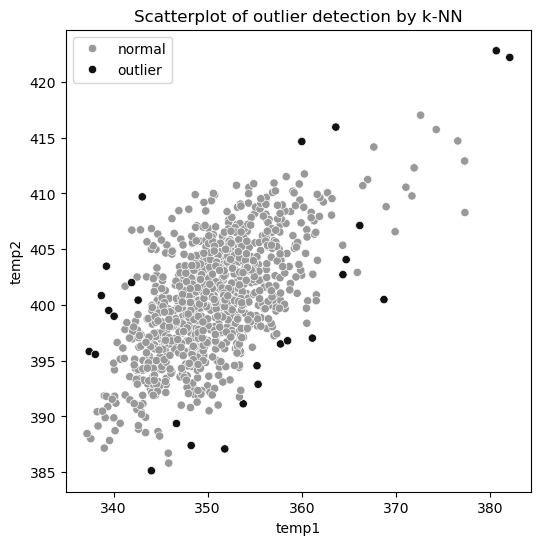

In [44]:
# コード9.6 LOF による外れ値検出
from sklearn.neighbors import LocalOutlierFactor

N_NEIGHBORS = 10  # kの値

# LOF用インスタンス作成
lof = LocalOutlierFactor(n_neighbors=N_NEIGHBORS, contamination='auto')
# 標準化とパイプライン化する
pipe = Pipeline([("scaler", StandardScaler()), ("lof", lof)])
# 学習データに対して標準化とLOFを適用
y_train_pred =pipe.fit_predict(X_train)  # 外れ値が-1、正常値が1で出力される
outlier_prediction = np.where(y_train_pred == -1, 'outlier', 'normal')
# 散布図で可視化
plt.figure(figsize=(6, 6))
sns.scatterplot(x=X_train[:, 0], y=X_train[:, 1],  #散布図
                hue=outlier_prediction,
                palette=['#999999', '#111111'])
plt.title("Scatterplot of outlier detection by k-NN")
plt.xlabel("temp1")
plt.ylabel("temp2")

k-NNは周囲の点からの距離に着目して外れ値を判定していましたが、LOFではそれを発展させて、周囲の点と比べて「データの存在密度」が高いかどうかに着目して外れ値を判定しています。
マハラノビス距離、k-NN、LOFにおいてそれぞれどのようなデータが外れ値として検出されるかを、以下にまとめます。

- マハラノビス距離：分布中心から離れるほど外れ値判定されやすくなる
- k-NN：周囲の点からの距離が遠いほど外れ値判定されやすくなる
- LOF：周囲の点と比べてデータ密度が低いほど外れ値判定されやすくなる

なお、scikit-learnのデフォルト設定では、LOFのしきい値として1.5を用いています。`LocalOutlierFactor`クラスのインスタンス作成時に、`contamination`引数に`0.01`のような数値を渡すことで、LOFの分位点に基づきしきい値を決定することができます。以下の例では、LOFの値が上位1%（0.01）のデータを外れ値として検出しています

Text(0, 0.5, 'temp2')

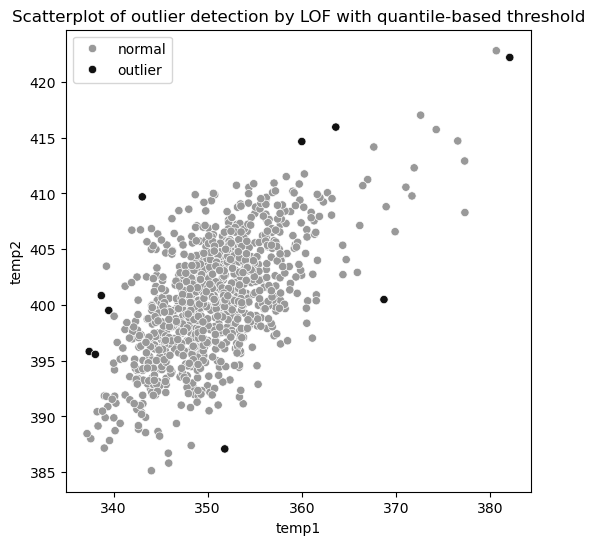

In [45]:
# LOFによる外れ値検出（分位点によるしきい値設定）
from sklearn.neighbors import LocalOutlierFactor

N_NEIGHBORS = 10  # kの値
DETECTION_RATE = 0.01  # 外れ値検出率

# LOF用インスタンス作成
lof = LocalOutlierFactor(n_neighbors=N_NEIGHBORS, contamination=DETECTION_RATE)
# 標準化とパイプライン化する
pipe = Pipeline([("scaler", StandardScaler()), ("lof", lof)])
# 学習データに対して標準化とLOFを適用
y_train_pred =pipe.fit_predict(X_train)  # 外れ値が-1、正常値が1で出力される
outlier_prediction = np.where(y_train_pred == -1, 'outlier', 'normal')
# 散布図で可視化
plt.figure(figsize=(6, 6))
sns.scatterplot(x=X_train[:, 0], y=X_train[:, 1],  #散布図
                hue=outlier_prediction,
                palette=['#999999', '#111111'])
plt.title("Scatterplot of outlier detection by LOF with quantile-based threshold")
plt.xlabel("temp1")
plt.ylabel("temp2")

### 5. OC-SVM

**OC-SVM**（one-class support vector machine）とは、3章で解説した教師あり学習手法であるSVMを、教師なし学習に応用した手法です。SVMでは各クラス間の決定境界をデータから学習していましたが、OC-SVMでは以下の図のように、全てのデータを原点から見て決定境界の反対側に置きつつ、原点からの距離を最大化するように決定境界を決めます。

![fig9_ocsvm.png](https://raw.githubusercontent.com/ghmagazine/python_anomaly_detection_book/refs/heads/main/notebooks/images/fig9_ocsvm.png)

一見すると、実際のデータでは原点に対して都合よく片側に集まらないように思えますが、カーネル変換後の特徴空間ではデータが原点から離れた特定の方向に偏る傾向があるので、このような決定境界の引き方が効果を発揮するそうです（すなわち、カーネルトリックの利用が前提の手法）。

線形かつハードマージンのOC-SVMでは、カーネルトリックなしのSVMと同様に超平面で決定境界を引きます。超平面の方程式は

$w_1 x_1 + \cdots + w_M x_M -\rho=\boldsymbol{w}^{\top}\boldsymbol{x}-\rho=0$

で表され、OC-SVMでは制約条件として$\rho>0$（決定境界の下側に原点、上側にデータが来るようにする）を加えます。
このとき、原点からこの超平面までの距離は$\frac{\rho}{\|\boldsymbol{w}\|}$となり、また全てのデータ$i$に関して$\boldsymbol{w}^{\top}\boldsymbol{x}^{(i)} \geq \rho$（データが超平面の上にある）が成り立つ必要があります。よってOC-SVMの学習は以下の最適化問題で表現できます。

<img src="https://latex.codecogs.com/svg.image?
\begin{align}
&\max_{\boldsymbol{w},\rho} \frac{\rho}{\|\boldsymbol{w}\|}\\
&\mathrm{s.t.} \quad \boldsymbol{w}^{\top}\boldsymbol{x}^{(i)} \geq \rho \quad (i = 1, 2, ...N)
\end{align}
" />

実際のデータでは以下のような問題が発生することが一般的なため、SVMと同様にカーネルトリックとソフトマージンを用いて対策します。

- データが原点から見て1方向に集まらない（線形分離不可能） → **カーネルトリック**で非線形な決定境界を引く
- 間違い（学習データが決定境界の外側に出る）を1個も許さないと過学習を起こす → **ソフトマージン**で一定量の間違いを許容

OC-SVMの理論の詳細については[[竹内 2015]](https://www.kspub.co.jp/book/detail/1529069.html)等を参照してください。

PythonでOC-SVMは、scikit-learnの[sklearn.svm.OneClassSVM](https://scikit-learn.org/stable/modules/generated/sklearn.svm.OneClassSVM.html)クラスで実装できます。LOFやk-NNと同様に特徴空間上での距離に基づく方法のため、前処理として標準化を実施する必要があります。以下に標準化とOC-SVMをパイプラインし、外れ値検出に用いる実装例を示します。

Text(0, 0.5, 'temp2')

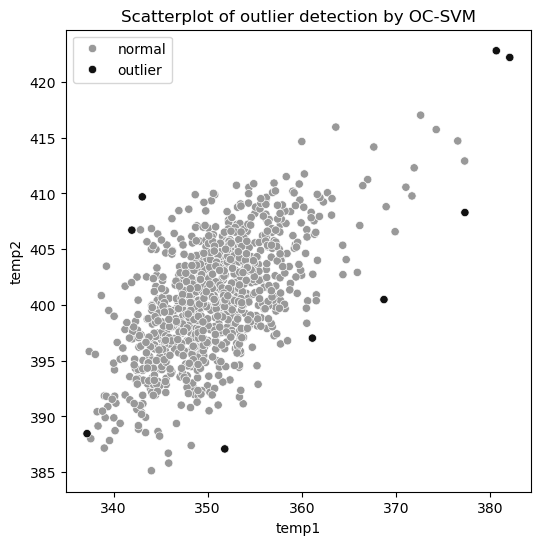

In [46]:
# OC-SVMによる外れ値検出
from sklearn.svm import OneClassSVM

DETECTION_RATE = 0.01  # 外れ値検出率

# OC-SVM用インスタンス作成
ocsvm = OneClassSVM(nu=DETECTION_RATE, kernel="rbf", gamma=0.1)
# 標準化とパイプライン化する
pipe = Pipeline([("scaler", StandardScaler()), ("ocsvm", ocsvm)])
# 学習データに対して標準化とLOFを適用
y_train_pred =pipe.fit_predict(X_train)  # 外れ値が-1、正常値が1で出力される
outlier_prediction = np.where(y_train_pred == -1, 'outlier', 'normal')
# 散布図で可視化
plt.figure(figsize=(6, 6))
sns.scatterplot(x=X_train[:, 0], y=X_train[:, 1],  #散布図
                hue=outlier_prediction,
                palette=['#999999', '#111111'])
plt.title("Scatterplot of outlier detection by OC-SVM")
plt.xlabel("temp1")
plt.ylabel("temp2")

ソフトマージンでの間違いの許容割合、すなわち学習データのうち何%を外れ値として検出するかは、`nu`引数で指定できます。